# 🫀 Previsão de Doença Cardíaca com Regressão Logística

**Disciplina**: PAM0466 – Sistemas Inteligentes – UFERSA

**Docente**: Pedro Thiago Valério de Souza

**Semestre**: 2026.1

**Data**: 20/04/2026

# INTRODUÇÃO E CONTEXTO

Doenças cardiovasculares são a principal causa de morte no mundo, responsáveis por cerca de 18 milhões de óbitos por ano segundo a OMS. O diagnóstico precoce é determinante para o sucesso do tratamento. Existe, portanto, uma necessidade real de ferramentas capazes de estimar o risco de um paciente com base em dados clínicos simples, coletados em consulta de rotina. É nesse contexto que o aprendizado de máquina pode contribuir. Um modelo de classificação treinado com dados históricos de pacientes diagnosticados é capaz de aprender quais combinações de variáveis clínicas estão associadas à presença de doença cardíaca e aplicar esse aprendizado a novos pacientes.

Neste projeto, você é convidado a construir um modelo utilizando regressão logística para prever a presença de doença cardíaca com base em um conjunto de dados clínicos.

# CONJUNTO DE DADOS

O projeto utiliza o dataset Heart Disease Cleveland (UCI Machine Learning Repository – disponível em <https://archive.ics.uci.edu/dataset/45/heart+disease>), com registros de 303 pacientes e 13 variáveis clínicas. Os diagnósticos foram confirmados por cateterismo cardíaco, o que garante rótulos confiáveis.

As variáveis incluem:

- age — idade do paciente em anos;
- sex — sexo biológico (1 = masculino, 0 = feminino);
- cp — tipo de dor no peito: angina típica (1), atípica (2), não anginosa (3) ou assintomático (4);
- trestbps — pressão arterial em repouso em mmHg;
- chol — colesterol sérico total em mg/dl;
- fbs — glicemia em jejum acima de 120 mg/dl (1 = sim, 0 = não);
- restecg — resultado do ECG em repouso: normal (0), alteração na onda ST-T (1) ou hipertrofia ventricular (2);
- thalach — frequência cardíaca máxima atingida no teste de esforço;
- exang — angina induzida por exercício (1 = sim, 0 = não);
- oldpeak — depressão do segmento ST durante o esforço, indicador de isquemia;
- slope — inclinação do segmento ST no pico do esforço: ascendente (1), plano (2) ou descendente (3);
- ca — número de artérias coronárias com obstrução visível na fluoroscopia (0 a 3);
- thal — cintilografia de tálio: normal (3), defeito fixo / infarto prévio (6) ou defeito reversível / isquemia ativa (7);

A saída é a variável target, que indica o diagnóstico original de 0 a 4, binarizado para 0 (sem doença) e 1 (com doença) antes do treinamento.

In [1]:
from ucimlrepo import fetch_ucirepo  # Pegar o dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt  # Plotar gráficos
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Pegando os Dados

In [2]:
# fetch dataset
heart_disease = fetch_ucirepo(id=45)  # Pegando o dataset

# data (as pandas dataframes)
X = heart_disease.data.features  # Pegando as variáveis
y = heart_disease.data.targets   # Pegando as classes

X  # Mostrando os dados

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


In [3]:
y  # Mostrando os dados de saída (classes)

,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


# Pré-processamento

(Questão) Realize o tratamento de valores nulos (verificar especialmente as colunas ca e thal). Caso existam, escolha o método de imputação através da mediana.

(Resposta) Foram identificados 4 valores nulos na coluna ca e 2 na coluna thal. Esse valores foram substituídos pela mediana dos valores contidos na colunas.

In [4]:
print(X.isnull().sum())  # Mostra a quantidade de valores nulos de cada coluna

X["ca"] = X["ca"].fillna(
    X["ca"].median()
)  # Adiciona a mediana dos valores da coluna aos valores nulos da coluna
X["thal"] = X["thal"].fillna(
    X["thal"].median()
)  # Adiciona a mediana dos valores da coluna aos valores nulos da coluna

print(20 * "-")  # Cria uma divisão com "-"
print(X.isnull().sum())  # Mostra a quantidade de valores nulos de cada coluna

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64
--------------------
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


(Questão) Obtenha a binarização da variável target, transformando os valores originais (0 a 4) em uma variável binaria (0 = sem doença, 1 = com doença).

(Resposta) Os valores 1, 2, 3 e 4 foram transformados em 1 e a variável 0 continuou sendo ela mesma.

In [5]:
y["num"] = (y["num"] > 0).astype(int)  # Transforma os valores 1, 2, 3, 4 em 1 e o valor 0 continua o mesmo
print(y["num"].value_counts())  # Mostra/conta a quantidade de valores de cada classe 0 ou 1
y  # Mostra o data frame das classes

num
0    164
1    139
Name: count, dtype: int64


,num
0,0
1,1
2,1
3,0
4,0
...,...
298,1
299,1
300,1
301,1


(Questão) Realize a divisão treino/teste com proporção de 80/20, usando stratify=y para preservar o balanceamento entre as classes.

(Resposta) Foi realizado a separação dos dados de treinamento (131 amostras da classe 0 (sem doença) e 111 da classe 1 (com doença)) e de teste (23 amostras da classe 0 e 28 da classe 1). stratify fez com que a divisão das classes fosse mais próxima possível.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,  # dataframe com os dados das variáveis
    y,  # dataframe contendo as classes
    test_size=0.2,  # divisão de 20% para teste e 80% para treino
    random_state=42,  # estado fixo para replicabilidade
    stratify=y.values.ravel()  # divisão mais próxima uma da outra
)

print(y_train["num"].value_counts())  # Mostra o número de valores do treino
print(y_test["num"].value_counts())   # Mostra o número de valores do teste

num
0    131
1    111
Name: count, dtype: int64
num
0    33
1    28
Name: count, dtype: int64


(Questão) Faça o escalonamento das features numéricas contínuas (age, trestbps, chol, thalach, oldpeak) com StandardScaler.

(Resposta) Foi aplicado o StandardScaler nas colunas ["age", "trestbps", "chol", "thalach", "oldpeak"] nas colunas para padronizar os valores, removendo a média e escalando para variância unitária (distribuição com média ≈ 0 e desvio padrão ≈ 1).

In [7]:
scaler = StandardScaler()  # Cria a escala para ajusta os valores contínuos das colunas

cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]  # Colunas a serem escaladas

X_train_sc = scaler.fit_transform(X_train[cols])  # Aplica no conjunto de treino
X_test_sc = scaler.transform(X_test[cols])        # Aplica no conjunto de teste.
                                                   # Sem o fit pois já foi utilizado no treino

X_train[cols] = X_train_sc  # Adiciona os valores escalados novamente ao dataframe
X_test[cols] = X_test_sc    # Adiciona os valores escalados novamente ao dataframe

X_train  # Mostra os valores do dataframe de treino

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,-0.729485,1,4,-0.395692,0.458139,0,2,0.708371,0,-0.445445,2,0.0,7.0
208,0.050166,1,2,-0.054513,0.230598,0,0,0.222495,0,-0.891627,1,0.0,3.0
167,-0.061212,0,2,0.059213,0.723605,1,2,0.399178,1,-0.891627,1,1.0,3.0
105,-0.061212,1,2,-1.305501,1.121803,0,0,0.266666,0,-0.891627,1,0.0,7.0
297,0.272924,0,4,0.514117,-0.167601,0,0,-1.190962,1,-0.713154,2,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.829818,0,4,0.514117,2.733557,0,2,0.310836,0,0.179210,2,0.0,3.0
136,1.720848,1,4,0.798433,-1.438042,0,0,-1.102621,1,1.428521,3,0.0,7.0
2,1.386712,1,4,-0.623144,-0.395142,0,2,-0.925938,1,1.428521,2,2.0,7.0
189,1.609469,1,3,0.514117,0.078903,0,2,-0.175039,0,0.893102,2,3.0,7.0


# Treinamento

(Questão) Treinar um modelo de LogisticRegression do scikit-learn utilizando os dados de treino, com os seguintes parâmetros: solver='liblinear', random state=42 e max iter=1000. Indique quantas iterações foram necessárias para a convergência do modelo.

(Resposta) Foi criado o modelo configurado:

- solver -> liblinear
- random_state -> 42
- max_iter -> 1000

Ao os dados para o método fit do modelo o dataframe y_train contentos as classes alvo precisou ser transformado em um array numpy recomendação da biblioteca scikit-learn. Foram necessárias 5 interações para o fim do treinamento no caso o modelo conseguiu em 5 interações identificar a melhor reta que divide no meio as classes.

In [8]:
model = LogisticRegression(  # cria o modelo de regressão logística
    solver="liblinear",  # Definir problemas lineares
    random_state=42,     # Define um estado para a replicabilidade
    max_iter=1000,       # Números de interações do modelo
)
model.fit(X_train, y_train.values.ravel())  # Treinamento: y_train.values.ravel() converte DataFrame para array 1D,
                                            # formato esperado pelo método fit() do scikit-learn

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [9]:
print(f"Iterações: {model.n_iter_[0]}")  # Mostra as interações realizadas pelo modelo

Iterações: 5


# Avaliação do Modelo

(Questão)

- Acurácia: Indica a performance geral do modelo, ou seja, quanto ele acertou do total.

- Precisão: Mede a proporção de verdadeiros positivos entre todas as predições positivas.

- Recall: Mede a proporção de verdadeiros positivos e dados realmente positivos.

- F1-score: É a média harmônica entre Precisão e Recall.

- Curva ROC com valor de AUC: A curva ROC (do inglês Receiver Operating Characteristic, ou Característica de Operação do Receptor) é uma ferramenta gráfica essencial para avaliar o desempenho de um modelo de classificação binária. Para resumir a curva ROC em um único valor numérico, utilizamos o AUC (Area Under the Curve). Quanto mais próximo de 1,0 for o valor do AUC, melhor é o nosso classificador.

(Resposta)

| Métrica  | Valor  | Interpretação |
|----------|--------|---------------|
| Acurácia | 0.8689 | ~87% das predições no conjunto de teste estão corretas. Bom desempenho geral. |
| Precisão | 0.8125 | Quando o modelo prevê "doença", ~81% das vezes está correto. ~19% são falsos positivos. |
| Recall   | 0.9286 | O modelo identifica ~93% dos pacientes realmente doentes. Apenas ~7% são falsos negativos. |
| F1-Score | 0.8667 | Média harmônica equilibrada entre precisão e recall, confirmando robustez do modelo. |
| AUC-ROC  | 0.9545 | Excelente capacidade discriminatória. Valores acima de 0.9 indicam separação eficaz das classes. |

In [10]:
y_pred = model.predict(X_test)               # Testa o modelo nos dados de teste
y_prob = model.predict_proba(X_test)[:, 1]   # Calcula a probabilidade dos dados de teste

Acurácia:  0.8689
Precisão:  0.8125
Recall:    0.9286
F1-Score:  0.8667
AUC-ROC:   0.9545


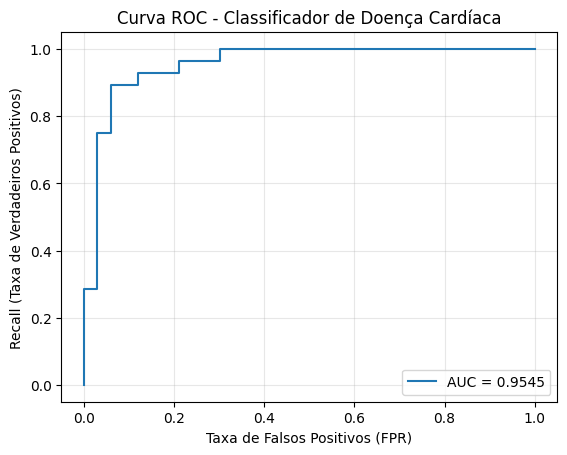

In [11]:
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")   # % de predições corretas no total
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")  # % de positivos previstos que são reais
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")     # de positivos reais que foram identificados
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")         # Média harmônica entre precisão e recall

fpr, tpr, thresholds = roc_curve(y_test, y_prob)  # Calcula taxas para plotar a curva ROC
auc = roc_auc_score(y_test, y_prob)               # Calcula a área sob a curva (resumo da performance)

print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")   # Exibe o valor do AUC

# Plotar
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")              # Desenha a curva ROC com legenda do AUC
plt.xlabel("Taxa de Falsos Positivos (FPR)")               # Rótulo do eixo X: probabilidade de alarme falso
plt.ylabel("Recall (Taxa de Verdadeiros Positivos)")       # Rótulo do eixo Y: sensibilidade do modelo
plt.title("Curva ROC - Classificador de Doença Cardíaca")  # Título descritivo do gráfico
plt.legend(loc="lower right")                              # Posiciona a legenda no canto inferior direito
plt.grid(alpha=0.3)  # Adiciona grade suave para melhor leitura
plt.show()           # Mostra o gráfico

# 🎯 Conclusão

O modelo demonstra alta adequação para uso como ferramenta de triagem auxiliar. 

**Por que o alto Recall é importante?**  
Na medicina, falsos negativos são geralmente mais críticos que falsos positivos, pois um paciente doente não tratado pode evoluir para quadros graves. O recall elevado (92,86%) atende bem a essa necessidade clínica.

**Sobre a precisão moderada:**  
A precisão de 81,25% indica que alguns pacientes saudáveis podem ser encaminhados para exames complementares — o que é aceitável em contextos de rastreio inicial, onde o custo de um falso positivo é menor que o de um falso negativo.

**Confiabilidade geral:**  
O AUC-ROC de 0,9545 reforça que o modelo é confiável e generaliza bem para os dados disponíveis, sendo uma base sólida para aplicações assistivas em saúde.